# Image Classification - Cats vs Dogs
## Transfer Learning with ResNet-50 | Keras / TensorFlow

---

| | |
|---|---|
| **Architecture** | ResNet-50 (Pre-trained on ImageNet) |
| **Task** | Binary Classification — Cat (1) / Dog (0) |
| **Technique** | Transfer Learning — Frozen Backbone + Dense Head |
| **Framework** | Keras / TensorFlow |

---

### 💡 Why Transfer Learning?
Instead of training a deep network from scratch — which requires millions of images and hours of compute — we leverage **ResNet-50** pre-trained on **ImageNet** (1.2M images, 1000 classes). The network already learned powerful features like edges, textures, and shapes. We only add a new output layer to adapt it to our Cats vs Dogs task.


## 1. 📦 Imports

In [1]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.applications import ResNet50
from keras.applications.resnet import preprocess_input
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

2026-04-08 14:55:54.916374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775660155.208733      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775660155.295970      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775660156.045281      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775660156.045338      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775660156.045341      17 computation_placer.cc:177] computation placer alr

## 2. 📂 Dataset Paths

> **Note:** Update these paths to match your dataset location.  
> On Kaggle they typically look like `/kaggle/input/<dataset-name>/training`.


In [2]:
TRAINPATH = r"/kaggle/input/datasets/abdullahbakr7/cats-vs-dogs-image-classification/Data/training"
TESTPATH  = r"/kaggle/input/datasets/abdullahbakr7/cats-vs-dogs-image-classification/Data/testing"

# Sanity check
print(f"Training images : {len(os.listdir(TRAINPATH))}")
print(f"Testing  images : {len(os.listdir(TESTPATH))}")

Training images : 1000
Testing  images : 200


## 3. 🏷️ Data Loading & Labeling

We scan the training directory and assign labels based on the filename prefix:
- Starts with `cat` → **Label = 1**
- Otherwise → **Label = 0** (Dog)


In [3]:
Train_Images = []
Train_Labels = []

for image in os.listdir(TRAINPATH):
    Label = 1 if image.startswith("cat") else 0  # cat=1, dog=0
    Train_Images.append(image)
    Train_Labels.append(Label)

dataframe = pd.DataFrame({"FileName": Train_Images, "ClassNum": Train_Labels})
dataframe.head(10)

,FileName,ClassNum
0,dog.4329.jpg,0
1,cat.4414.jpg,1
2,cat.4420.jpg,1
3,cat.4326.jpg,1
4,dog.4223.jpg,0
5,dog.4253.jpg,0
6,cat.4071.jpg,1
7,dog.4190.jpg,0
8,dog.4354.jpg,0
9,dog.4136.jpg,0


## 4. ✂️ Train / Validation Split

We split the data into **80% training** and **20% validation**.  
`random_state=33` ensures the same split every run.

> ⚠️ **Important:** Labels stay as integers — do NOT convert to strings. We use `class_mode='raw'` which reads numeric values directly.


In [4]:
Train_df, Test_df = train_test_split(dataframe, test_size=0.2, random_state=33)

print(f"Train size : {len(Train_df)}")
print(f"Val   size : {len(Test_df)}")
Train_df.head()

Train size : 800
Val   size : 200


,FileName,ClassNum
866,dog.4377.jpg,0
909,dog.4244.jpg,0
640,dog.4110.jpg,0
582,dog.4177.jpg,0
516,cat.4426.jpg,1


## 5. 📊 Class Distribution

We verify the dataset is **balanced**. A heavily imbalanced dataset would cause the model to bias toward the majority class.


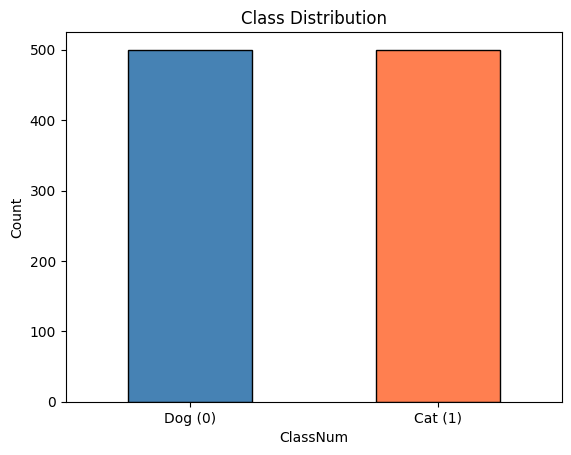

In [5]:
dataframe["ClassNum"].value_counts().plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
plt.xticks(ticks=[0, 1], labels=["Dog (0)", "Cat (1)"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

## 6. 🔄 Data Generators & Augmentation

We create **two separate generators**:

| Generator | Augmentation | Used for |
|---|---|---|
| `data_gen_fx` | ✅ Yes | Training only |
| `data_gen` | ❌ No | Validation & Prediction |

### Why augmentation on training only?
Augmentation increases data variety so the model generalizes better. Validation and test data must remain clean and unmodified we need to measure real-world performance.

### `class_mode='raw'` vs `'binary'`
`'raw'` passes your numeric labels as-is. `'binary'` re-encodes string labels alphabetically safe but less explicit. Since our labels are already integers, `'raw'` is the cleaner choice.


In [6]:
# Training generator — WITH augmentation
data_gen_fx = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    rotation_range=60,
    brightness_range=[0.5, 1.5]
)

# Validation / Test generator — preprocessing ONLY, no augmentation
data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = data_gen_fx.flow_from_dataframe(
    Train_df, TRAINPATH,
    x_col="FileName", y_col="ClassNum",
    target_size=(224, 224),
    class_mode="raw",   # return numeric labels as-is
    batch_size=10
)

test_gen = data_gen.flow_from_dataframe(
    Test_df, TRAINPATH,
    x_col="FileName", y_col="ClassNum",
    target_size=(224, 224),
    class_mode="raw",
    batch_size=10
)

Found 800 validated image filenames.
Found 200 validated image filenames.


## 7. 🏗️ Model Architecture

The model has two parts:
1. **ResNet-50 Backbone** (frozen) — extracts rich visual features
2. **Dense(1, sigmoid)** (trainable) — outputs the final binary prediction

```
Input (224 × 224 × 3)
        ↓
ResNet-50 (frozen) → Global Average Pooling → (2048,)
        ↓
Dense(1, sigmoid) → P(Cat) ∈ [0, 1]
```

- `include_top=False` removes the original 1000-class head  
- `pooling='avg'` applies Global Average Pooling after the last conv block — no `Flatten()` needed  
- `trainable=False` freezes all ResNet-50 weights so we don't overwrite ImageNet features


In [7]:
model = Sequential([
    ResNet50(
        include_top=False,    # remove the ImageNet classification head
        weights="imagenet",   # load pre-trained weights
        pooling="avg"         # Global Average Pooling → output shape (None, 2048)
    ),
    Dense(1, activation="sigmoid")  # binary output: P(Cat)
])

# Freeze ResNet-50 — preserve learned ImageNet features
model.layers[0].trainable = False

model.summary()

2026-04-08 14:56:27.267778: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. ⚙️ Compile

- **Adam** — adaptive learning rate, converges faster than plain SGD  
- **binary_crossentropy** — standard loss for binary classification with sigmoid output  


In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 9. 🚀 Training

`EarlyStopping` halts training if `val_loss` shows no improvement for 4 consecutive epochs.  
`restore_best_weights=True` automatically rolls back to the best checkpoint.


In [9]:
fit_hist = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6875 - loss: 0.5955 - val_accuracy: 0.9550 - val_loss: 0.1185
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 929ms/step - accuracy: 0.9569 - loss: 0.1261 - val_accuracy: 0.9800 - val_loss: 0.1035
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 75s 941ms/step - accuracy: 0.9755 - loss: 0.0765 - val_accuracy: 0.9850 - val_loss: 0.0770
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9843 - loss: 0.0583 - val_accuracy: 0.9850 - val_loss: 0.0671
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 75s 932ms/step - accuracy: 0.9832 - loss: 0.0611 - val_accuracy: 0.9850 - val_loss: 0.0541
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 924ms/step - accuracy: 0.9883 - loss: 0.0557 - val_accuracy: 0.9800 - val_loss: 0.0765
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9822 - loss: 0.0548 - val_accuracy: 0.9850 - val_loss: 0.0547
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 922ms/step - accuracy: 0.9838 - loss: 0.0435 - val_accuracy: 0.9

## 10. 📈 Training Curves

Plotting Loss and Accuracy curves helps diagnose model behavior:

| Pattern | Diagnosis | Fix |
|---|---|---|
| val_loss >> train_loss | Overfitting | More augmentation, add Dropout |
| Both losses high | Underfitting | Unfreeze more layers, more epochs |
| Both decreasing together | Good fit ✅ | Keep going |
| val_loss spikes erratically | LR too high | Reduce learning rate |


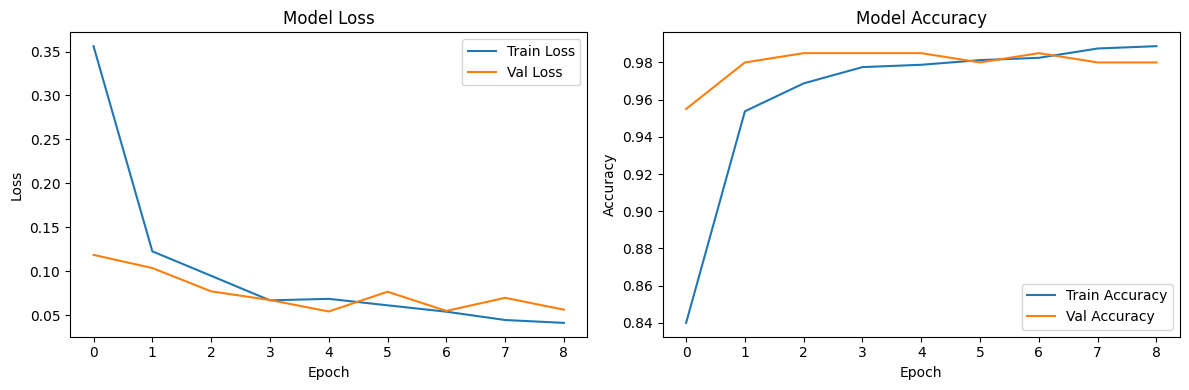

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fit_hist.history['loss'], label='Train Loss')
plt.plot(fit_hist.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fit_hist.history['accuracy'], label='Train Accuracy')
plt.plot(fit_hist.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 11. 🔮 Prediction Generator

We build a generator for test images with no labels:
- `class_mode=None` — no labels
- `shuffle=False` — **critical**: keeps `filenames[i]` aligned with `y_pred[i]`

> We use `flow_from_dataframe` instead of `flow_from_directory` because test images are flat in a single folder with no class subfolders.


In [11]:
pred_images = os.listdir(TESTPATH)
pred_df = pd.DataFrame({"FileName": pred_images})

pred_gen = data_gen.flow_from_dataframe(
    dataframe=pred_df,
    directory=TESTPATH,
    x_col="FileName",
    y_col=None,
    class_mode=None,
    target_size=(224, 224),
    batch_size=1,
    shuffle=False        # must be False — preserves filename ↔ prediction order
)

print(f"Test images found: {len(pred_gen)}")

Found 200 validated image filenames.
Test images found: 200


## 12. 🎯 Run Predictions

The model outputs a probability between 0 and 1.  
`np.round()` converts it to a hard label:
- **1.0 → Cat**
- **0.0 → Dog**


In [12]:
pred_gen.reset()   # reset generator pointer to the beginning
y_pred = model.predict(pred_gen)
y_pred = [np.round(i) for i in y_pred]

print("First 10 predictions:", y_pred[:10])

200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step
First 10 predictions: [array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32)]


In [13]:
pred_df.head()

,FileName
0,dog.4970.jpg
1,cat.4594.jpg
2,dog.4989.jpg
3,dog.4945.jpg
4,cat.4560.jpg


In [14]:
len(pred_gen)

200

In [15]:
y_pred[:10]

[array([0.], dtype=float32),
 array([1.], dtype=float32),
 array([0.], dtype=float32),
 array([0.], dtype=float32),
 array([1.], dtype=float32),
 array([1.], dtype=float32),
 array([0.], dtype=float32),
 array([0.], dtype=float32),
 array([1.], dtype=float32),
 array([1.], dtype=float32)]

## 13. 🖼️ Visualize Predictions

We randomly sample 25 test images and display them in a 5×5 grid with their predicted label.

> 💡 We use `mpimg.imread()` instead of `cv2.imread()` — Matplotlib reads images in RGB directly so no BGR→RGB conversion is needed.


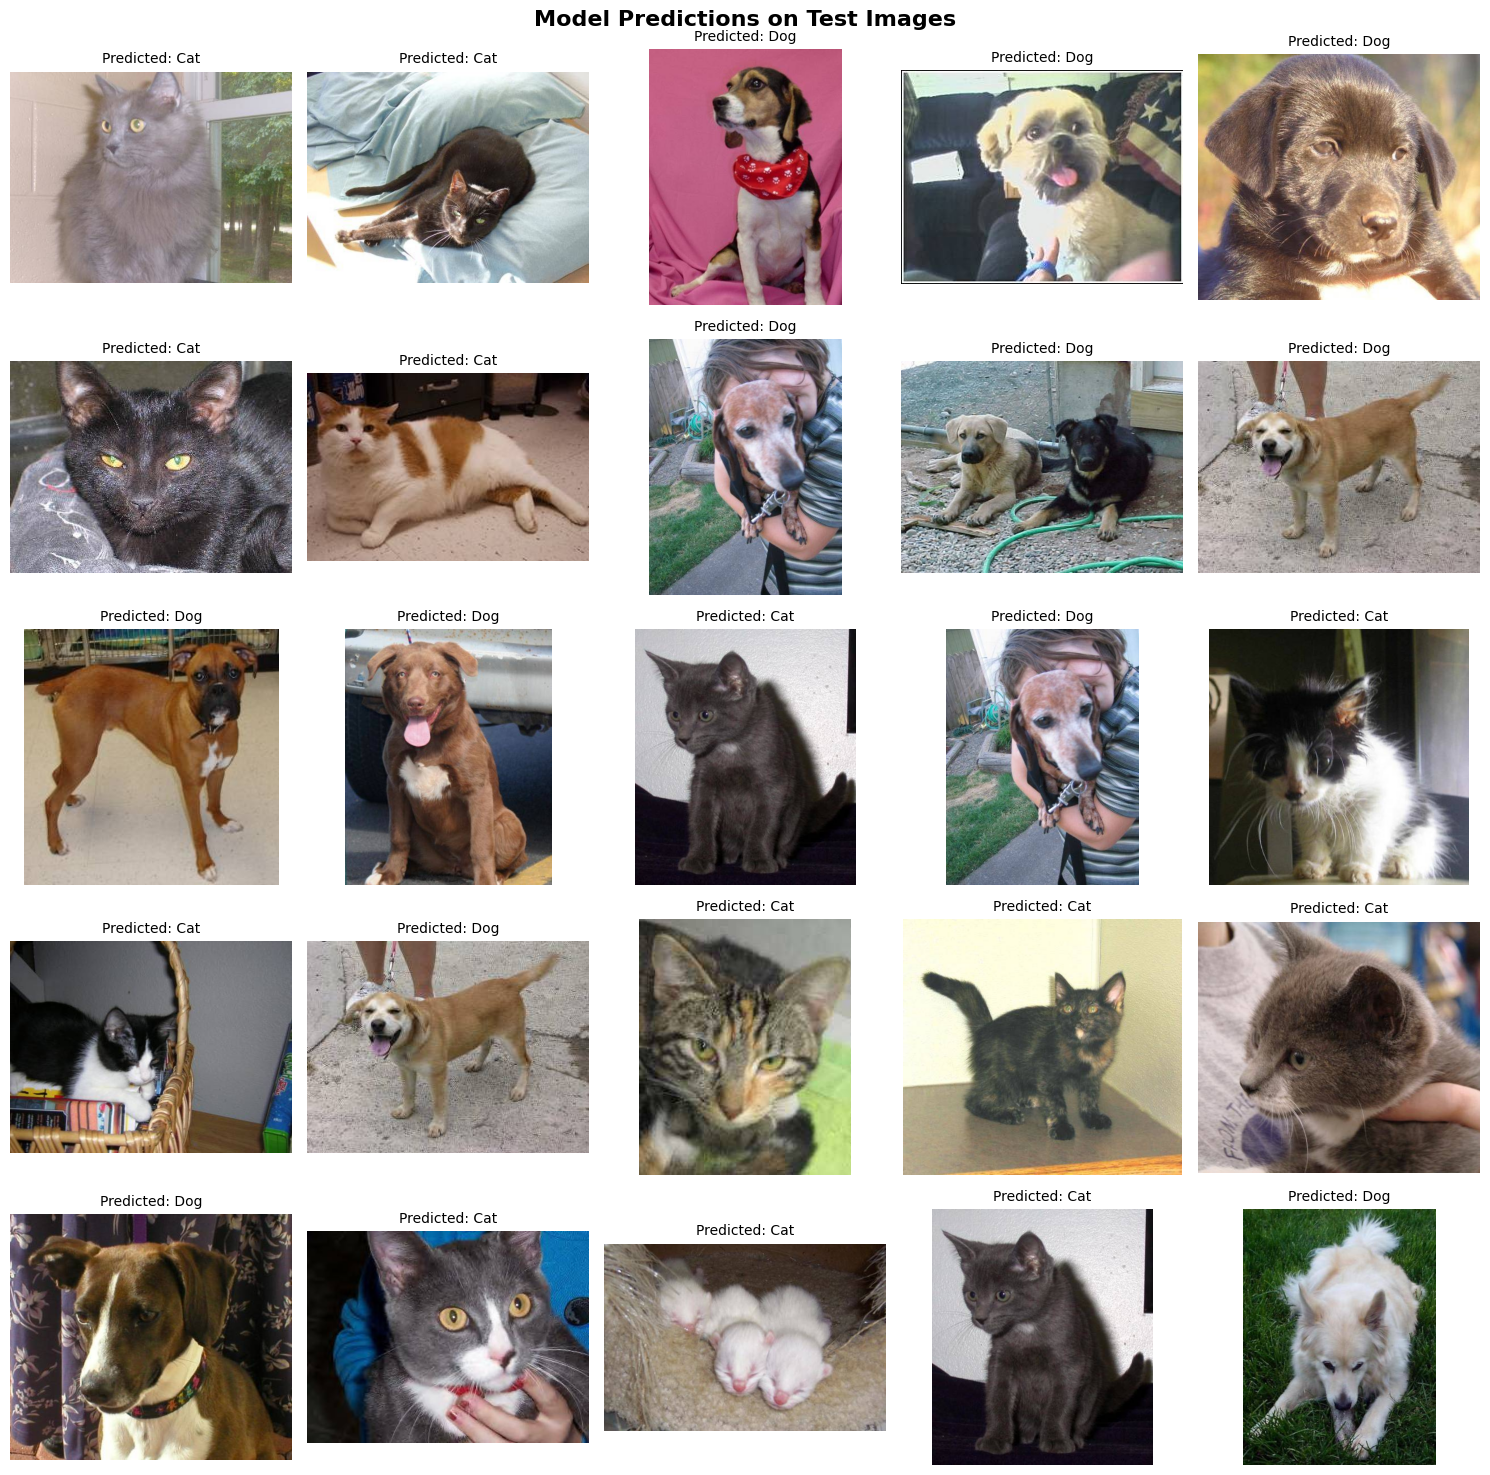

In [16]:
f, ax = plt.subplots(5, 5, figsize=(15, 15))

for i, idx in enumerate(np.random.randint(200, size=25)):
    img = mpimg.imread(os.path.join(TESTPATH, pred_gen.filenames[idx]))
    predicted_class = "Cat" if y_pred[idx][0] else "Dog"

    ax[i//5, i%5].imshow(img)
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Predicted: {predicted_class}", fontsize=10)

plt.suptitle("Model Predictions on Test Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()